# Supply Chain Risk & Interdependent Security

Your security posture is not determined by your controls alone. It is
determined by the intersection of your controls and your vendors'
controls, your vendors' vendors' controls, and the shared infrastructure
underneath all of it.

This is the problem of **interdependent security** (Kunreuther & Heal,
2003): each organization's risk depends on the security investments of
others in the network. You can have a perfect patch cadence, world-class
SOC, and zero known vulnerabilities -- and still get breached because
your HVAC vendor reuses passwords.

Supply chain risk is not additive. It is not even linear. It exhibits
correlation, contagion, and cascade dynamics that make naive
risk calculations dangerously wrong.

This notebook builds up from the simplest model (independent vendor
failures) to correlated failures, cascade propagation, and optimal
investment -- showing at each step how the standard assumptions break
and what the actual risk looks like.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.montecarlo import simulate_aggregate_losses, make_lognormal_severity, var_es
from decision_security.survival import km_estimator
from decision_security.viz import plot_km

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"

## 1. Your Risk Is Not Just Yours

Organization A depends on three vendors: B, C, and D. Each vendor has an
independent probability of suffering a breach that exposes A's data or
systems. A breach at *any* vendor compromises A.

Under independence, A's compound exposure is:

$$P(\text{A exposed}) = 1 - \prod_{i} (1 - p_i)$$

This is the inclusion-exclusion principle. Each additional vendor
multiplies the survival probability by a factor less than 1, so the
compound exposure grows superlinearly in vendor count. Adding a vendor
with "only" 3% breach probability still ratchets up A's total exposure
meaningfully -- because it compounds on top of everything else.

In [2]:
# --- Compound vendor exposure under independence ---

vendor_probs = {"Vendor B": 0.05, "Vendor C": 0.08, "Vendor D": 0.12}

# Compound exposure: 1 - product(1 - p_i)
probs = list(vendor_probs.values())
compound_3 = 1.0 - np.prod([1 - p for p in probs])

print("Individual vendor breach probabilities:")
for name, p in vendor_probs.items():
    print(f"  {name}: {p:.0%}")
print(f"\nCompound exposure (3 vendors): {compound_3:.1%}")
print(f"Sum of individual probs:        {sum(probs):.1%}")
print(f"\nThe compound is slightly less than the sum (because of")
print(f"overlap), but the key insight is: A's risk is far higher")
print(f"than any single vendor's risk.")

# Now add a 4th vendor with just 3% risk
vendor_probs_4 = {**vendor_probs, "Vendor E": 0.03}
probs_4 = list(vendor_probs_4.values())
compound_4 = 1.0 - np.prod([1 - p for p in probs_4])

print(f"\n--- Adding Vendor E (3% breach probability) ---")
print(f"Compound exposure (4 vendors): {compound_4:.1%}")
print(f"Marginal increase from Vendor E: {compound_4 - compound_3:.1%}")

Individual vendor breach probabilities:
  Vendor B: 5%
  Vendor C: 8%
  Vendor D: 12%

Compound exposure (3 vendors): 23.1%
Sum of individual probs:        25.0%

The compound is slightly less than the sum (because of
overlap), but the key insight is: A's risk is far higher
than any single vendor's risk.

--- Adding Vendor E (3% breach probability) ---
Compound exposure (4 vendors): 25.4%
Marginal increase from Vendor E: 2.3%


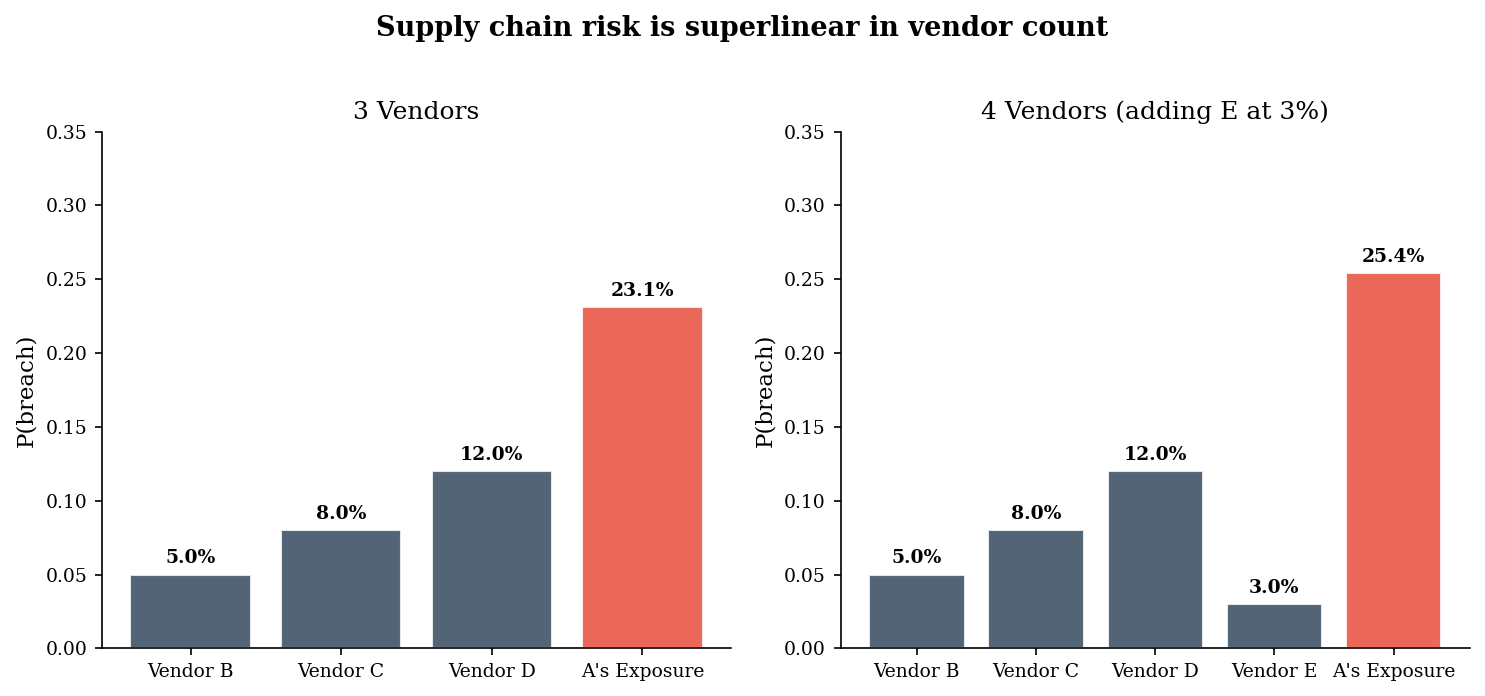


--- Scaling: N vendors each with 5% breach probability ---
   1 vendors: P(A exposed) = 5.0%
   3 vendors: P(A exposed) = 14.3%
   5 vendors: P(A exposed) = 22.6%
  10 vendors: P(A exposed) = 40.1%
  15 vendors: P(A exposed) = 53.7%
  20 vendors: P(A exposed) = 64.2%


In [3]:
# --- Bar chart: individual vendor risk vs compound exposure ---

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left panel: 3 vendors + compound
ax = axes[0]
labels_3 = list(vendor_probs.keys()) + ["A's Exposure"]
values_3 = list(vendor_probs.values()) + [compound_3]
colors_3 = [DARK_BG] * 3 + [ACCENT]
bars = ax.bar(labels_3, values_3, color=colors_3, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, values_3):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("P(breach)")
ax.set_title("3 Vendors")
ax.set_ylim(0, 0.35)

# Right panel: 4 vendors + compound
ax = axes[1]
labels_4 = list(vendor_probs_4.keys()) + ["A's Exposure"]
values_4 = list(vendor_probs_4.values()) + [compound_4]
colors_4 = [DARK_BG] * 4 + [ACCENT]
bars = ax.bar(labels_4, values_4, color=colors_4, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, values_4):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("P(breach)")
ax.set_title("4 Vendors (adding E at 3%)")
ax.set_ylim(0, 0.35)

fig.suptitle("Supply chain risk is superlinear in vendor count",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# Show scaling curve: compound exposure vs number of vendors at 5% each
print("\n--- Scaling: N vendors each with 5% breach probability ---")
for n in [1, 3, 5, 10, 15, 20]:
    compound = 1 - (1 - 0.05) ** n
    print(f"  {n:>2} vendors: P(A exposed) = {compound:.1%}")

## 2. Correlated Failures

The independence assumption in Section 1 is convenient but wrong.
Vendors share infrastructure (AWS, Azure), run the same software
(Log4j, MOVEit, SolarWinds Orion), face the same threat actors, and
get assessed by the same third-party rating services.

When SolarWinds was compromised in 2020, it was not one vendor that
failed -- it was the update mechanism that 18,000 organizations depended
on. Log4Shell in 2021 was not one vulnerability -- it was a dependency
embedded in hundreds of thousands of applications.

We model this with a **common-cause factor**: with probability
$p_{\text{systemic}} = 0.15$, a systemic event occurs that breaches ALL
vendors simultaneously. Otherwise, vendors fail independently as before.

The correlated model produces a loss distribution with a much fatter
tail -- the same expected loss, perhaps, but far more catastrophic
worst cases. This is exactly the kind of risk that VaR and ES are
designed to capture.

In [4]:
# --- Independent vs Correlated vendor failure model ---

N_SIM = 10_000
vendor_p = np.array([0.05, 0.08, 0.12])  # individual breach probs
vendor_loss = np.array([500_000, 800_000, 1_200_000])  # loss if vendor breached
p_systemic = 0.15  # probability of common-cause event

# --- Independent model ---
losses_independent = np.zeros(N_SIM)
for i in range(N_SIM):
    breached = rng.random(len(vendor_p)) < vendor_p
    losses_independent[i] = vendor_loss[breached].sum()

# --- Correlated model (common-cause factor) ---
losses_correlated = np.zeros(N_SIM)
for i in range(N_SIM):
    if rng.random() < p_systemic:
        # Systemic event: all vendors breached simultaneously
        losses_correlated[i] = vendor_loss.sum()
    else:
        # No systemic event: independent failures
        breached = rng.random(len(vendor_p)) < vendor_p
        losses_correlated[i] = vendor_loss[breached].sum()

# Compare distributions
var95_ind, es95_ind = var_es(losses_independent, alpha=0.95)
var95_cor, es95_cor = var_es(losses_correlated, alpha=0.95)

print(f"{'Metric':<25} {'Independent':>14} {'Correlated':>14}")
print(f"{'':─<25} {'':─>14} {'':─>14}")
print(f"{'Mean loss':<25} ${losses_independent.mean():>12,.0f} ${losses_correlated.mean():>12,.0f}")
print(f"{'Median loss':<25} ${np.median(losses_independent):>12,.0f} ${np.median(losses_correlated):>12,.0f}")
print(f"{'VaR (95%)':<25} ${var95_ind:>12,.0f} ${var95_cor:>12,.0f}")
print(f"{'ES (95%)':<25} ${es95_ind:>12,.0f} ${es95_cor:>12,.0f}")
print(f"{'P(loss > $1M)':<25} {(losses_independent > 1_000_000).mean():>14.1%} {(losses_correlated > 1_000_000).mean():>14.1%}")
print(f"{'P(total wipeout)':<25} {(losses_independent >= vendor_loss.sum()).mean():>14.2%} {(losses_correlated >= vendor_loss.sum()).mean():>14.2%}")
print(f"\nCorrelation inflates VaR95 by {var95_cor / max(var95_ind, 1) :.1f}x")
print(f"and ES95 by {es95_cor / max(es95_ind, 1):.1f}x.")

Metric                       Independent     Correlated
───────────────────────── ────────────── ──────────────
Mean loss                 $     230,750 $     575,760
Median loss               $           0 $           0
VaR (95%)                 $   1,200,000 $   2,500,000
ES (95%)                  $   1,436,727 $   2,500,000
P(loss > $1M)                      12.2%          25.7%
P(total wipeout)                   0.04%         15.13%

Correlation inflates VaR95 by 2.1x
and ES95 by 1.7x.


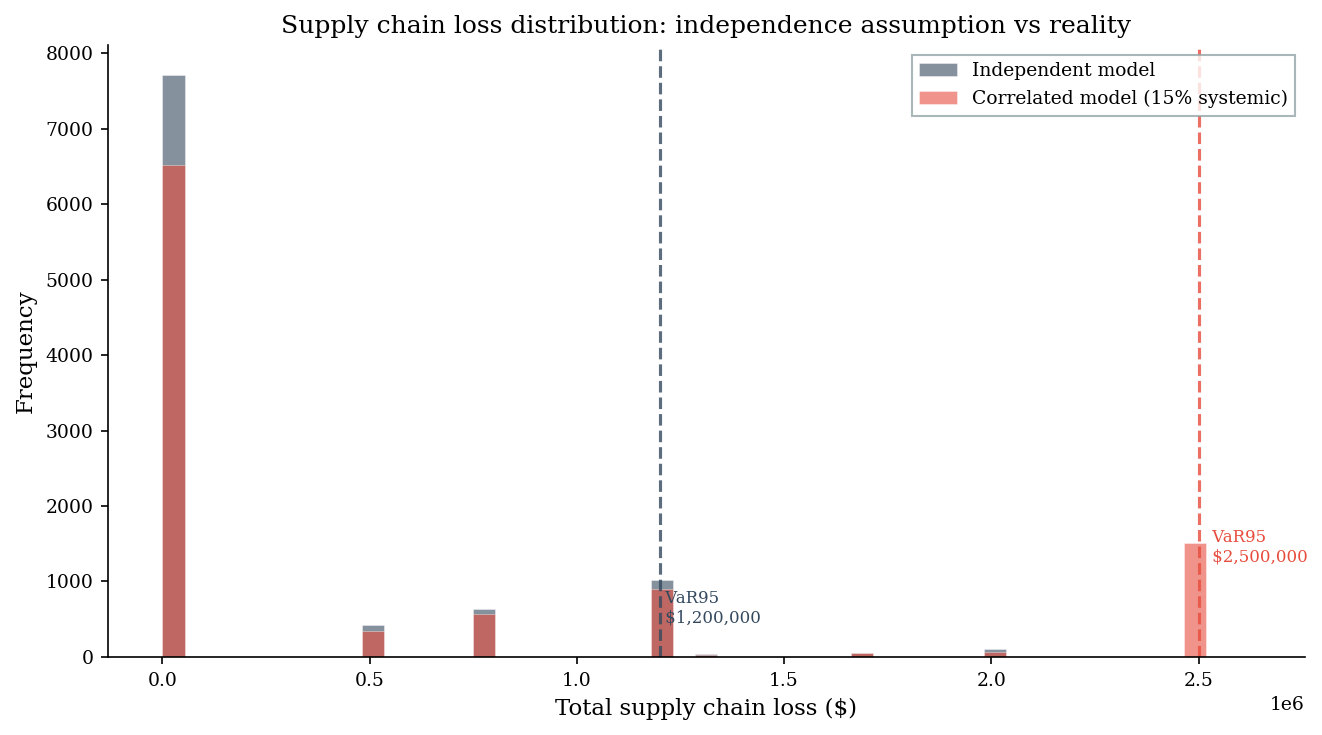

The spike at $2.5M in the correlated model is the systemic event --
all three vendors breached at once. This outcome is invisible in the
independent model but occurs ~15% of the time in reality.


In [5]:
# --- Overlapping histograms: independent vs correlated ---

fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(0, vendor_loss.sum() * 1.05, 50)

ax.hist(losses_independent, bins=bins, alpha=0.6, color=DARK_BG,
        label="Independent model", edgecolor="white", linewidth=0.3)
ax.hist(losses_correlated, bins=bins, alpha=0.6, color=ACCENT,
        label="Correlated model (15% systemic)", edgecolor="white", linewidth=0.3)

# VaR lines
ax.axvline(var95_ind, color=DARK_BG, linestyle="--", linewidth=1.5, alpha=0.8)
ax.axvline(var95_cor, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.8)

ax.text(var95_ind, ax.get_ylim()[1] * 0.05, f" VaR95\n ${var95_ind:,.0f}",
        fontsize=8, color=DARK_BG, va="bottom")
ax.text(var95_cor + 20_000, ax.get_ylim()[1] * 0.15, f" VaR95\n ${var95_cor:,.0f}",
        fontsize=8, color=ACCENT, va="bottom")

ax.set_xlabel("Total supply chain loss ($)")
ax.set_ylabel("Frequency")
ax.set_title("Supply chain loss distribution: independence assumption vs reality")
ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor=LIGHT_GRAY)

fig.tight_layout()
plt.show()

print("The spike at $2.5M in the correlated model is the systemic event --")
print("all three vendors breached at once. This outcome is invisible in the")
print("independent model but occurs ~15% of the time in reality.")

## 3. Cascade Dynamics

Beyond correlation, breaches can **propagate**: a compromised vendor
becomes a launch point for attacking its customers and partners.
SolarWinds was not just a correlated failure -- the compromised update
mechanism was used to actively push malware to downstream organizations.

We model a 10-node network where each node is connected to several
others. A breach at any node propagates to each connected neighbor
with probability $p_{\text{propagate}} = 0.3$ per edge. Starting with
one compromised node, we iterate until no new nodes are compromised.

The resulting distribution of **cascade size** (total nodes ultimately
compromised) is heavy-tailed: most cascades are small (1-2 nodes),
but some reach most of the network. The average cascade size is a
misleading statistic -- a decision-maker who plans for the mean is
ignoring exactly the scenarios that matter.

In [6]:
# --- Cascade simulation on a 10-node network ---

N_NODES = 10
P_PROPAGATE = 0.3
N_CASCADE_SIM = 1_000

# Build an adjacency list: random graph with ~30% edge density
# (fixed for reproducibility)
adj = {i: [] for i in range(N_NODES)}
edge_rng = make_rng(99)  # separate seed for graph structure
for i in range(N_NODES):
    for j in range(i + 1, N_NODES):
        if edge_rng.random() < 0.3:
            adj[i].append(j)
            adj[j].append(i)

n_edges = sum(len(v) for v in adj.values()) // 2
print(f"Network: {N_NODES} nodes, {n_edges} edges")
print(f"Adjacency (node: neighbors):")
for node, neighbors in adj.items():
    print(f"  Node {node}: {neighbors}")


def simulate_cascade(adj, start_node, p_propagate, rng):
    """BFS cascade: each compromised node infects each neighbor with probability p."""
    compromised = {start_node}
    frontier = [start_node]
    while frontier:
        next_frontier = []
        for node in frontier:
            for neighbor in adj[node]:
                if neighbor not in compromised:
                    if rng.random() < p_propagate:
                        compromised.add(neighbor)
                        next_frontier.append(neighbor)
        frontier = next_frontier
    return len(compromised)


# Run 1000 simulations, starting from node 0 each time
cascade_sizes = np.array([
    simulate_cascade(adj, 0, P_PROPAGATE, rng)
    for _ in range(N_CASCADE_SIM)
])

print(f"\nCascade size distribution ({N_CASCADE_SIM} simulations):")
print(f"  Mean:   {cascade_sizes.mean():.1f} nodes")
print(f"  Median: {np.median(cascade_sizes):.0f} nodes")
print(f"  P(>= 5 nodes): {(cascade_sizes >= 5).mean():.1%}")
print(f"  P(>= 8 nodes): {(cascade_sizes >= 8).mean():.1%}")
print(f"  Max cascade:   {cascade_sizes.max()} nodes")

Network: 10 nodes, 12 edges
Adjacency (node: neighbors):
  Node 0: [7]
  Node 1: [4, 7]
  Node 2: [5, 6]
  Node 3: []
  Node 4: [1, 5, 6, 7, 8, 9]
  Node 5: [2, 4, 6]
  Node 6: [2, 4, 5, 9]
  Node 7: [0, 1, 4]
  Node 8: [4]
  Node 9: [4, 6]

Cascade size distribution (1000 simulations):
  Mean:   1.7 nodes
  Median: 1 nodes
  P(>= 5 nodes): 7.7%
  P(>= 8 nodes): 1.4%
  Max cascade:   9 nodes


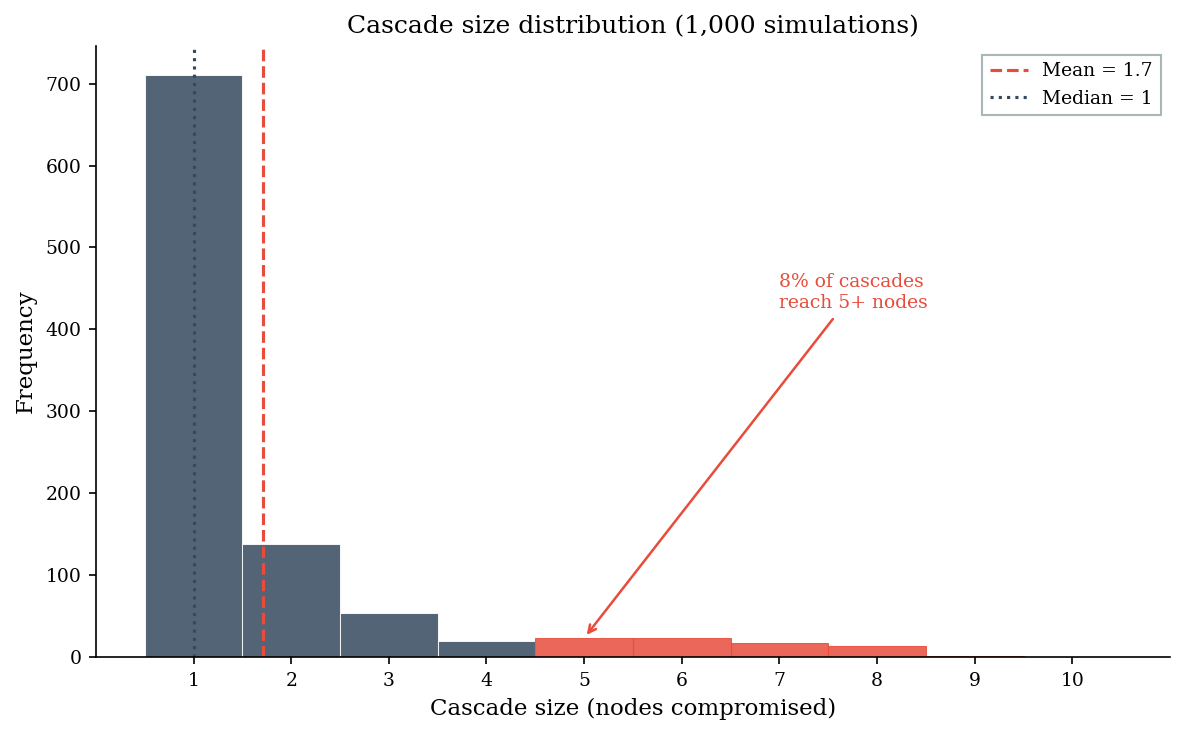

Most cascades stay small -- the median is the typical experience.
But the tail events are where the real damage lives. A decision-maker
who plans for the average is ignoring exactly the scenarios that justify
supply chain security investment.


In [7]:
# --- Distribution of cascade sizes ---

fig, ax = plt.subplots(figsize=(8, 5))

counts, edges, bars = ax.hist(cascade_sizes, bins=np.arange(0.5, N_NODES + 1.5, 1),
                               color=DARK_BG, alpha=0.85, edgecolor="white",
                               linewidth=0.5)

# Color the tail bars differently
for i, bar in enumerate(bars):
    if edges[i] + 0.5 >= 5:  # 5+ nodes = tail event
        bar.set_color(ACCENT)
        bar.set_alpha(0.85)

# Annotate mean and median
ax.axvline(cascade_sizes.mean(), color=ACCENT, linestyle="--", linewidth=1.5,
           label=f"Mean = {cascade_sizes.mean():.1f}")
ax.axvline(np.median(cascade_sizes), color=DARK_BG, linestyle=":", linewidth=1.5,
           label=f"Median = {np.median(cascade_sizes):.0f}")

ax.set_xlabel("Cascade size (nodes compromised)")
ax.set_ylabel("Frequency")
ax.set_title("Cascade size distribution (1,000 simulations)")
ax.set_xticks(range(1, N_NODES + 1))
ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor=LIGHT_GRAY)

# Annotate tail
tail_pct = (cascade_sizes >= 5).mean()
ax.annotate(f"{tail_pct:.0%} of cascades\nreach 5+ nodes",
            xy=(5, counts[4] if len(counts) > 4 else 0),
            xytext=(7, max(counts) * 0.6),
            fontsize=9, color=ACCENT,
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.2))

fig.tight_layout()
plt.show()

print("Most cascades stay small -- the median is the typical experience.")
print("But the tail events are where the real damage lives. A decision-maker")
print("who plans for the average is ignoring exactly the scenarios that justify")
print("supply chain security investment.")

## 4. Time-to-Compromise Across the Supply Chain

Organizations that actively assess and monitor their vendors' security
posture survive longer before a supply chain compromise. The mechanism
is straightforward: vendor assessments identify weak links, trigger
remediation, and occasionally lead to vendor replacement -- all of
which delay the time until a vendor-originated breach.

We generate time-to-compromise data for 50 organizations in each group
(with and without vendor assessment programs) and use Kaplan-Meier
survival curves to compare them. The expected result: vendor assessment
adds meaningful survival time, but it does not eliminate supply chain
risk -- only delays it.

In [8]:
# --- Time-to-compromise: vendor assessment vs no assessment ---

N_ORGS = 50
CENSOR_AT = 36  # months -- observation window

# Organizations WITHOUT vendor assessments: shorter survival times
# Weibull with shape < 1 (decreasing hazard early, but low scale = fast events)
times_no_assess = sample("weibull", N_ORGS, rng=rng, k=1.2, lam=14.0)
events_no_assess = np.ones(N_ORGS, dtype=int)
# Right-censor at observation window
censored = times_no_assess > CENSOR_AT
times_no_assess[censored] = CENSOR_AT
events_no_assess[censored] = 0

# Organizations WITH vendor assessments: longer survival times
times_with_assess = sample("weibull", N_ORGS, rng=rng, k=1.3, lam=22.0)
events_with_assess = np.ones(N_ORGS, dtype=int)
censored = times_with_assess > CENSOR_AT
times_with_assess[censored] = CENSOR_AT
events_with_assess[censored] = 0

# Kaplan-Meier estimates
km_t_no, km_s_no = km_estimator(times_no_assess, events_no_assess)
km_t_yes, km_s_yes = km_estimator(times_with_assess, events_with_assess)

# Compute median survival (time where S(t) first drops below 0.5)
def median_survival(km_t, km_s):
    idx = np.where(km_s <= 0.5)[0]
    return float(km_t[idx[0]]) if len(idx) > 0 else float('inf')

med_no = median_survival(km_t_no, km_s_no)
med_yes = median_survival(km_t_yes, km_s_yes)

print(f"Median time-to-compromise:")
print(f"  Without vendor assessment: {med_no:.1f} months")
print(f"  With vendor assessment:    {med_yes:.1f} months")
print(f"  Difference:                {med_yes - med_no:+.1f} months")
print(f"\nEvents observed (of {N_ORGS} orgs):")
print(f"  Without assessment: {events_no_assess.sum()} breached, {N_ORGS - events_no_assess.sum()} censored")
print(f"  With assessment:    {events_with_assess.sum()} breached, {N_ORGS - events_with_assess.sum()} censored")

Median time-to-compromise:
  Without vendor assessment: 7.7 months
  With vendor assessment:    13.3 months
  Difference:                +5.6 months

Events observed (of 50 orgs):
  Without assessment: 47 breached, 3 censored
  With assessment:    44 breached, 6 censored


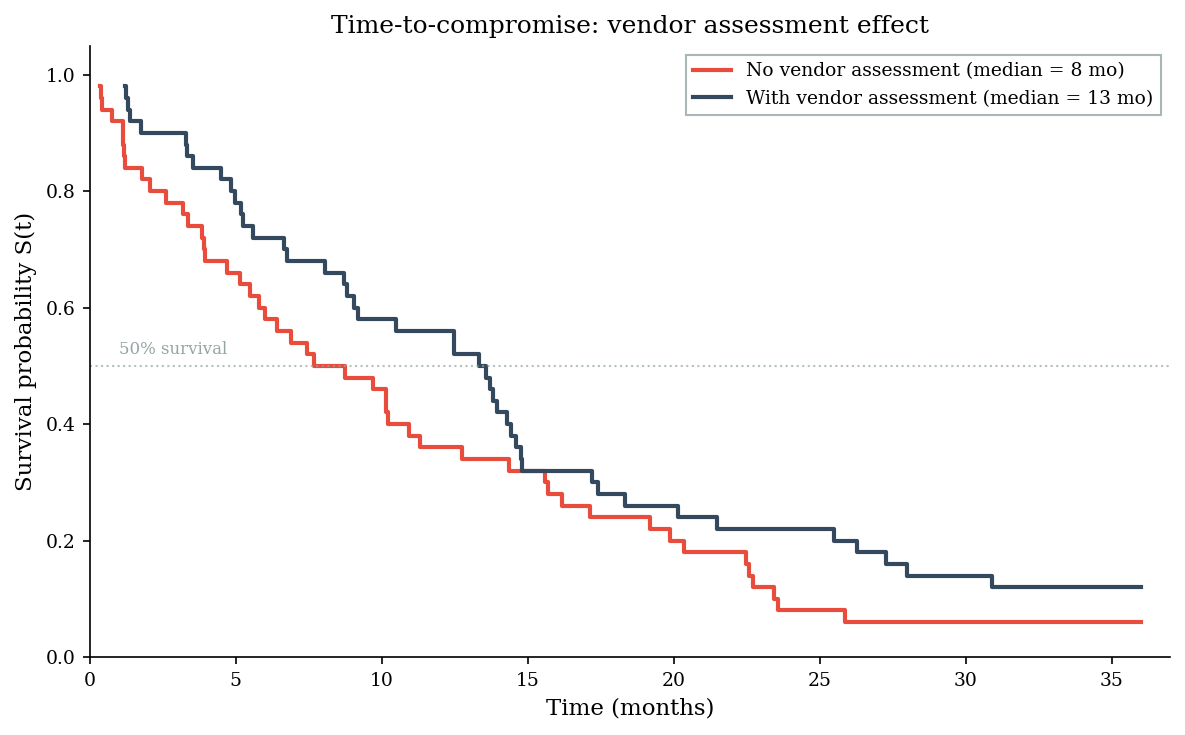

Vendor security assessments do not prevent supply chain compromise --
but they buy meaningful time. Time that can be used for detection,
incident preparation, and reducing the blast radius when a vendor
breach eventually occurs.


In [9]:
# --- Kaplan-Meier survival curves ---

fig, ax = plt.subplots(figsize=(8, 5))

# Plot both curves using ax.step for full control over style
ax.step(km_t_no, km_s_no, where="post", color=ACCENT, linewidth=2,
        label=f"No vendor assessment (median = {med_no:.0f} mo)")
ax.step(km_t_yes, km_s_yes, where="post", color=DARK_BG, linewidth=2,
        label=f"With vendor assessment (median = {med_yes:.0f} mo)")

# Median survival lines
ax.axhline(0.5, color=LIGHT_GRAY, linestyle=":", linewidth=1, alpha=0.7)
ax.text(1, 0.52, "50% survival", fontsize=8, color=LIGHT_GRAY)

ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival probability S(t)")
ax.set_title("Time-to-compromise: vendor assessment effect")
ax.set_xlim(0, CENSOR_AT + 1)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor=LIGHT_GRAY)

fig.tight_layout()
plt.show()

print("Vendor security assessments do not prevent supply chain compromise --")
print("but they buy meaningful time. Time that can be used for detection,")
print("incident preparation, and reducing the blast radius when a vendor")
print("breach eventually occurs.")

## 5. Optimal Vendor Security Investment

You have $100K to invest in vendor security. Three strategies:

| Strategy | Description | Mechanism |
|:---------|:------------|:----------|
| **(a) Spread audit** | $25K per vendor (4 vendors) | Reduces each vendor's P(breach) by 20% |
| **(b) Deep audit** | $100K on highest-risk vendor (D) | Reduces vendor D's P(breach) by 60% |
| **(c) Contractual controls** | $100K on SLAs and contracts | Caps loss at 50% when a vendor breach occurs |

Strategy (a) is the diversified approach -- spread the investment.
Strategy (b) is targeted -- fix the weakest link.
Strategy (c) is transfer -- accept breaches will happen, limit the damage.

We compare the loss distributions under each strategy using Monte Carlo.

In [10]:
# --- Optimal investment: 3 strategies ---

N_SIM = 10_000

# Baseline: 4 vendors
vendor_names = ["Vendor B", "Vendor C", "Vendor D", "Vendor E"]
base_probs = np.array([0.05, 0.08, 0.12, 0.03])
base_losses = np.array([500_000, 800_000, 1_200_000, 300_000])


def simulate_supply_chain(probs, losses, loss_cap=None, n_sim=10_000, rng=rng):
    """Monte Carlo: total loss from vendor breaches."""
    total_losses = np.zeros(n_sim)
    for i in range(n_sim):
        breached = rng.random(len(probs)) < probs
        if breached.any():
            event_losses = losses[breached]
            if loss_cap is not None:
                event_losses = event_losses * loss_cap
            total_losses[i] = event_losses.sum()
    return total_losses


# Baseline (no investment)
losses_baseline = simulate_supply_chain(base_probs, base_losses)

# Strategy (a): spread audit -- 20% reduction in each vendor's P(breach)
probs_a = base_probs * 0.80
losses_a = simulate_supply_chain(probs_a, base_losses)

# Strategy (b): deep audit -- 60% reduction in vendor D's P(breach)
probs_b = base_probs.copy()
probs_b[2] = probs_b[2] * 0.40  # vendor D index 2
losses_b = simulate_supply_chain(probs_b, base_losses)

# Strategy (c): contractual controls -- cap loss at 50% on any vendor breach
losses_c = simulate_supply_chain(base_probs, base_losses, loss_cap=0.50)

# Compare
strategies = {
    "Baseline (no investment)": losses_baseline,
    "(a) Spread audit ($25K x 4)": losses_a,
    "(b) Deep audit ($100K on D)": losses_b,
    "(c) Contractual SLAs ($100K)": losses_c,
}

print(f"{'Strategy':<30} {'E[Loss]':>12} {'VaR95':>12} {'ES95':>12}")
print(f"{'':─<30} {'':─>12} {'':─>12} {'':─>12}")
for name, losses in strategies.items():
    v, e = var_es(losses, alpha=0.95)
    print(f"{name:<30} ${losses.mean():>10,.0f} ${v:>10,.0f} ${e:>10,.0f}")

Strategy                            E[Loss]        VaR95         ES95
────────────────────────────── ──────────── ──────────── ────────────
Baseline (no investment)       $   237,470 $ 1,200,000 $ 1,428,743
(a) Spread audit ($25K x 4)    $   194,820 $ 1,200,000 $ 1,361,078
(b) Deep audit ($100K on D)    $   157,130 $ 1,200,000 $ 1,311,377
(c) Contractual SLAs ($100K)   $   117,025 $   600,000 $   706,587


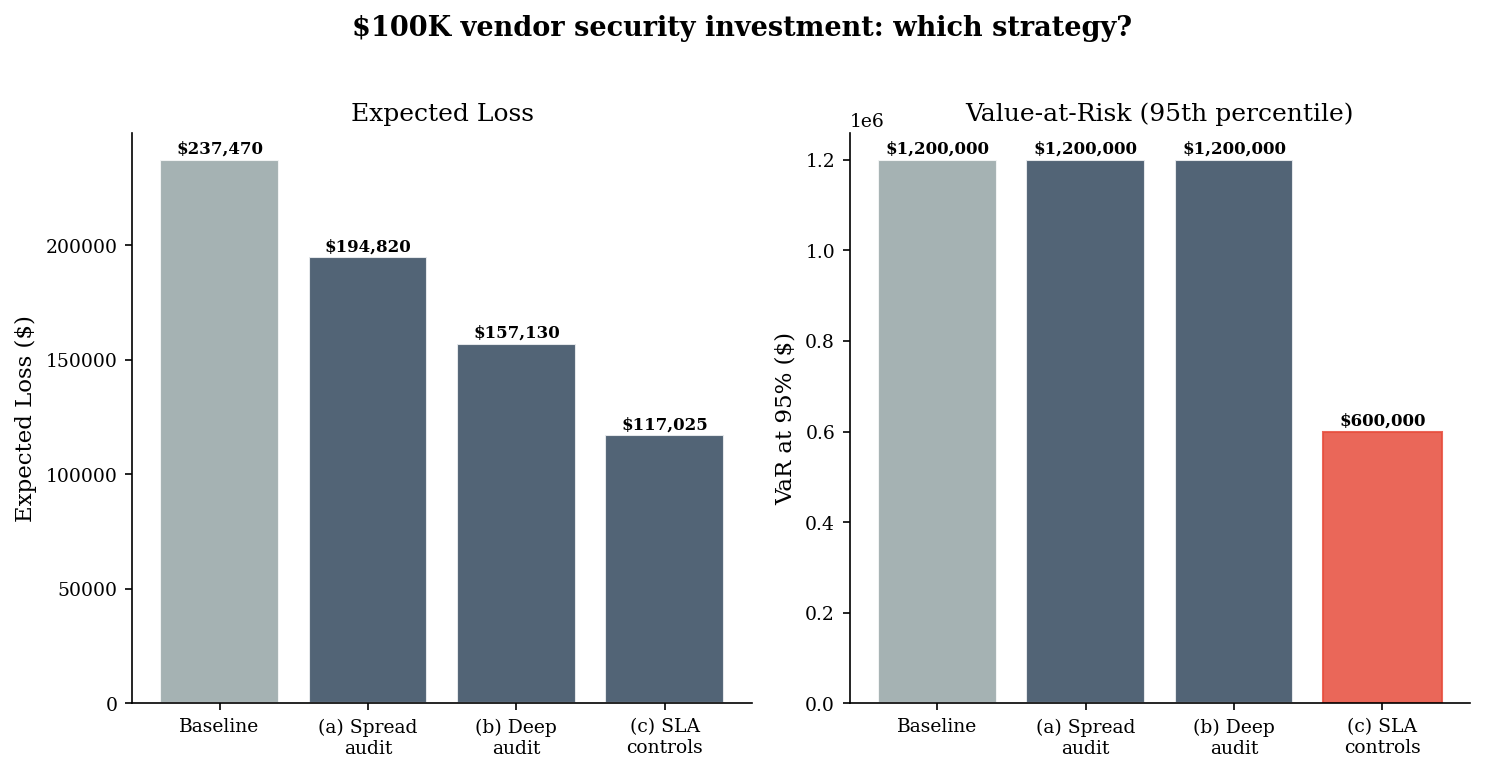

Strategy (c) -- contractual controls -- consistently reduces both
expected loss and VaR95. It does not prevent breaches, but it caps
the damage. Strategy (b) -- deep audit on the worst vendor -- is
effective at reducing the tail, but leaves the other vendors untouched.
Strategy (a) -- spread thin -- provides modest improvement everywhere
but does not meaningfully shift the tail.


In [11]:
# --- Bar chart: expected loss and VaR95 by strategy ---

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

strat_labels = ["Baseline", "(a) Spread\naudit", "(b) Deep\naudit", "(c) SLA\ncontrols"]
strat_colors = [LIGHT_GRAY, DARK_BG, DARK_BG, DARK_BG]

# Expected loss
ax = axes[0]
means = [l.mean() for l in strategies.values()]
bars = ax.bar(strat_labels, means, color=strat_colors, alpha=0.85, edgecolor="white")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 1000,
            f"${m:,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_ylabel("Expected Loss ($)")
ax.set_title("Expected Loss")

# VaR95
ax = axes[1]
var95s = [var_es(l, alpha=0.95)[0] for l in strategies.values()]
bars = ax.bar(strat_labels, var95s, color=strat_colors, alpha=0.85, edgecolor="white")
# Highlight the best VaR95
best_idx = np.argmin(var95s[1:]) + 1  # exclude baseline
bars[best_idx].set_color(ACCENT)
for bar, v in zip(bars, var95s):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 5000,
            f"${v:,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_ylabel("VaR at 95% ($)")
ax.set_title("Value-at-Risk (95th percentile)")

fig.suptitle("$100K vendor security investment: which strategy?",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print("Strategy (c) -- contractual controls -- consistently reduces both")
print("expected loss and VaR95. It does not prevent breaches, but it caps")
print("the damage. Strategy (b) -- deep audit on the worst vendor -- is")
print("effective at reducing the tail, but leaves the other vendors untouched.")
print("Strategy (a) -- spread thin -- provides modest improvement everywhere")
print("but does not meaningfully shift the tail.")

## 6. Pitfalls

**Independence assumptions dramatically understate supply chain tail risk.**
Vendors share cloud providers, software dependencies, and threat actor
attention. Treating vendor failures as independent is not conservative --
it is optimistic. The correlated model shows how a 15% common-cause
factor can double VaR and create a fat tail that the independence model
cannot see.

**Vendor count is a risk factor, not just a management challenge.**
Each additional vendor compounds exposure superlinearly. Twenty vendors
at 5% each produce a 64% compound exposure -- not 100%, but far more
than the 5% each one contributes individually. Vendor consolidation is
a risk reduction strategy, not just a procurement efficiency.

**Systemic risk cannot be diversified away -- it is the opposite of
diversification.** In financial portfolios, diversification reduces
variance. In supply chains, adding vendors increases correlation
exposure: more vendors means more shared infrastructure, more common
dependencies, and higher probability that a single systemic event
(Log4j, SolarWinds, MOVEit) hits multiple links simultaneously.

**Contractual controls (SLAs) shift losses, they do not prevent them.**
An SLA that guarantees breach notification within 72 hours does not
prevent the breach. An indemnification clause caps your financial
exposure but does not protect your customers' data. Contracts are
loss transfer mechanisms, and treating them as loss prevention overstates
their value.

**The weakest vendor sets your floor.** If your riskiest vendor has a
12% annual breach probability, your supply chain exposure cannot be
lower than 12% no matter how secure the other vendors are. Targeted
investment in the weakest link (strategy b) often outperforms spreading
the same budget evenly -- but only when you can correctly identify which
vendor is weakest.

**Cascade models show that average case is irrelevant -- plan for the
tail.** The mean cascade size is small, which is reassuring. But the
distribution is heavy-tailed: a small fraction of cascades reach most
of the network. The expected case is one compromised node; the bad case
is eight. Risk management is about the bad case.